# Customer Lifetime Value (CLV) Analysis

This notebook calculates and predicts Customer Lifetime Value using multiple methods:
1. **Simple CLV** - Formula-based calculation
2. **RFM-Weighted CLV** - Leveraging RFM scores
3. **ML-Predicted CLV** - Gradient Boosting regression

**Input:** `data/customers_with_segments.csv`  
**Output:** `data/customers_with_clv.csv`

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load data from segmentation output
df = pd.read_csv('data/customers_with_segments.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (5000, 40)

Columns: ['age', 'gender', 'income', 'education', 'marital_status', 'household_size', 'region', 'urban_rural', 'total_purchases_12m', 'total_spend_12m', 'avg_order_value', 'days_since_last_purchase', 'product_categories_purchased', 'returns_rate', 'discount_usage_rate', 'loyalty_program_member', 'email_open_rate', 'email_click_rate', 'website_visits_30d', 'avg_session_duration', 'mobile_app_usage', 'social_media_engagement', 'push_notification_enabled', 'sms_opt_in', 'purchased_product_a', 'kmeans_cluster', 'hierarchical_cluster', 'dbscan_cluster', 'gmm_cluster', 'rfm_segment', 'purchase_propensity', 'propensity_segment', 'rfm_tier', 'propensity_tier', 'combined_segment', 'action_segment', 'engagement_score', 'engagement_tier', 'segment_3d', 'action_segment_3d']


In [3]:
# Quick data overview
df.head()

,age,gender,income,education,marital_status,household_size,region,urban_rural,total_purchases_12m,total_spend_12m,...,purchase_propensity,propensity_segment,rfm_tier,propensity_tier,combined_segment,action_segment,engagement_score,engagement_tier,segment_3d,action_segment_3d
0,49,Male,60701,Bachelor,Married,2,Southwest,Urban,13,576.94,...,0.153177,Very Low,Medium Value,Low Propensity,Medium Value / Low Propensity,6. Fence Sitter - Engage,0.398826,High Engagement,Medium Value | High Engagement | Low Propensity,9. Fading Interest - Re-engage
1,39,Male,37033,High School,Married,4,Southwest,Suburban,14,741.65,...,0.147779,Very Low,Medium Value,Low Propensity,Medium Value / Low Propensity,6. Fence Sitter - Engage,0.259809,Low Engagement,Medium Value | Low Engagement | Low Propensity,10. Dormant - Minimal Effort
2,51,Male,63185,Master,Widowed,1,Southeast,Suburban,25,2045.20,...,0.277666,Low,High Value,Low Propensity,High Value / Low Propensity,3. At-Risk VIP - Win Back,0.328387,Medium Engagement,High Value | Medium Engagement | Low Propensity,9. Fading Interest - Re-engage
3,64,Male,104063,Bachelor,Married,4,Midwest,Suburban,10,889.58,...,0.207887,Low,Medium Value,Low Propensity,Medium Value / Low Propensity,6. Fence Sitter - Engage,0.193364,Low Engagement,Medium Value | Low Engagement | Low Propensity,10. Dormant - Minimal Effort
4,38,Male,83414,Bachelor,Married,1,Northeast,Suburban,22,2071.67,...,0.670879,High,High Value,High Propensity,High Value / High Propensity,1. VIP - Retain & Upsell,0.217907,Low Engagement,High Value | Low Engagement | High Propensity,2. VIP Ready - Convert Now


## 2. CLV Feature Engineering

### 2.1 Recalculate RFM Scores
We need individual R, F, M scores for the RFM-weighted CLV method.

In [4]:
# Recalculate RFM scores (1-5 scale)
# Recency: lower days = higher score (more recent = better)
df['R_Score'] = pd.qcut(df['days_since_last_purchase'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher purchases = higher score
df['F_Score'] = pd.qcut(df['total_purchases_12m'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher spend = higher score
df['M_Score'] = pd.qcut(df['total_spend_12m'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM Score (3-15 range)
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

print("RFM Score Distribution:")
print(df['RFM_Score'].describe())

RFM Score Distribution:
count    5000.000000
mean        9.048200
std         3.695701
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_Score, dtype: float64


### 2.2 Customer Lifespan Estimation

Estimate customer lifespan based on:
- Base lifespan (loyalty members vs non-members)
- Engagement multiplier
- Recency adjustment

In [5]:
# Base lifespan based on loyalty status
df['base_lifespan'] = np.where(df['loyalty_program_member'] == 1, 3.5, 2.0)

# Engagement multiplier (based on email and digital engagement)
engagement_multiplier = (
    1.0
    + 0.15 * (df['email_open_rate'] > 0.3).astype(float)
    + 0.10 * (df['website_visits_30d'] > 10).astype(float)
    + 0.10 * (df['mobile_app_usage'] > 10).astype(float)
)

# Recency penalty (inactive customers have shorter expected lifespan)
recency_multiplier = np.where(
    df['days_since_last_purchase'] > 60, 0.7,
    np.where(df['days_since_last_purchase'] > 30, 0.85, 1.0)
)

# Returns penalty (high returns = lower satisfaction = shorter lifespan)
returns_multiplier = np.where(df['returns_rate'] > 0.2, 0.85, 1.0)

# Calculate final lifespan estimate
df['customer_lifespan_years'] = (
    df['base_lifespan'] 
    * engagement_multiplier 
    * recency_multiplier 
    * returns_multiplier
)

print("Customer Lifespan Distribution (years):")
print(df['customer_lifespan_years'].describe())

Customer Lifespan Distribution (years):
count    5000.000000
mean        2.641342
std         0.963840
min         1.190000
25%         1.870000
50%         2.200000
75%         3.570000
max         4.725000
Name: customer_lifespan_years, dtype: float64


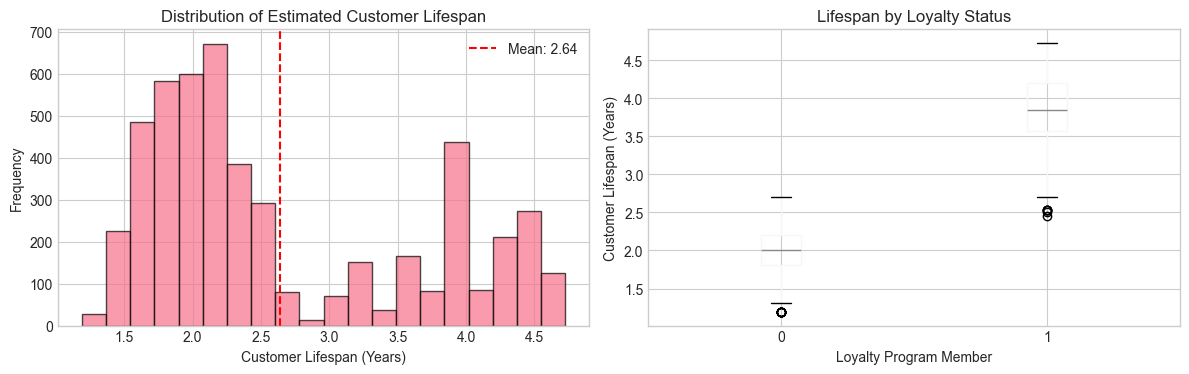

In [6]:
# Visualize lifespan distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['customer_lifespan_years'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Customer Lifespan (Years)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Estimated Customer Lifespan')
axes[0].axvline(df['customer_lifespan_years'].mean(), color='red', linestyle='--', label=f"Mean: {df['customer_lifespan_years'].mean():.2f}")
axes[0].legend()

# By loyalty status
df.boxplot(column='customer_lifespan_years', by='loyalty_program_member', ax=axes[1])
axes[1].set_xlabel('Loyalty Program Member')
axes[1].set_ylabel('Customer Lifespan (Years)')
axes[1].set_title('Lifespan by Loyalty Status')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 3. CLV Calculation Methods

### 3.1 Simple CLV
**Formula:** `CLV = avg_order_value × purchase_frequency × customer_lifespan`

In [7]:
# Simple CLV calculation
df['purchase_frequency_annual'] = df['total_purchases_12m']  # Already annualized

df['clv_simple'] = (
    df['avg_order_value'] 
    * df['purchase_frequency_annual'] 
    * df['customer_lifespan_years']
)

print("Simple CLV Distribution:")
print(df['clv_simple'].describe())
print(f"\nTotal Simple CLV: ${df['clv_simple'].sum():,.0f}")

Simple CLV Distribution:
count     5000.000000
mean      3242.542651
std       2761.631768
min         70.672000
25%       1301.112000
50%       2277.384000
75%       4408.998563
max      20403.825750
Name: clv_simple, dtype: float64

Total Simple CLV: $16,212,713


### 3.2 RFM-Weighted CLV
**Formula:** `CLV = total_spend_12m × (1 + RFM_Score/15) × customer_lifespan`

Higher RFM scores get a bonus multiplier (up to 2x for perfect RFM score of 15).

In [8]:
# RFM-weighted CLV
rfm_multiplier = 1 + (df['RFM_Score'] / 15)  # Range: 1.2 to 2.0

df['clv_rfm_weighted'] = (
    df['total_spend_12m'] 
    * rfm_multiplier 
    * df['customer_lifespan_years']
)

print("RFM-Weighted CLV Distribution:")
print(df['clv_rfm_weighted'].describe())
print(f"\nTotal RFM-Weighted CLV: ${df['clv_rfm_weighted'].sum():,.0f}")

RFM-Weighted CLV Distribution:
count     5000.000000
mean      5743.671721
std       5576.847567
min         84.806400
25%       1810.601550
50%       3706.276800
75%       7910.627340
max      40808.313000
Name: clv_rfm_weighted, dtype: float64

Total RFM-Weighted CLV: $28,718,359


### 3.3 ML-Predicted CLV

Use Gradient Boosting to predict CLV based on all available features.

**Challenge:** We don't have actual future CLV data, so we create a proxy target that combines value signals.

In [9]:
# Create CLV proxy target for ML training
# This combines multiple value indicators into a synthetic CLV target
df['clv_proxy'] = (
    df['total_spend_12m'] * 1.5                           # Base value (1.5 year projection)
    + df['avg_order_value'] * df['total_purchases_12m'] * 0.5  # Growth potential
    - df['days_since_last_purchase'] * 5                  # Recency penalty
    + df['loyalty_program_member'] * 500                  # Loyalty bonus
    - df['returns_rate'] * df['total_spend_12m'] * 0.5    # Returns penalty
    + df['engagement_score'] * 300                        # Engagement bonus
)

# Floor at 0
df['clv_proxy'] = np.maximum(df['clv_proxy'], 0)

print("CLV Proxy Target Distribution:")
print(df['clv_proxy'].describe())

CLV Proxy Target Distribution:
count     5000.000000
mean      2255.051457
std       1408.174428
min          0.000000
25%       1206.202082
50%       2017.754080
75%       3041.135156
max      10379.788070
Name: clv_proxy, dtype: float64


In [10]:
# Features for CLV prediction
clv_features = [
    'age', 'income', 'household_size',
    'total_purchases_12m', 'avg_order_value', 'days_since_last_purchase',
    'product_categories_purchased', 'returns_rate', 'discount_usage_rate',
    'loyalty_program_member', 'email_open_rate', 'email_click_rate',
    'website_visits_30d', 'avg_session_duration', 'mobile_app_usage',
    'social_media_engagement', 'engagement_score',
    'R_Score', 'F_Score', 'M_Score'
]

X = df[clv_features].copy()
y = df['clv_proxy'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4000 samples
Test set: 1000 samples


In [11]:
# Train Gradient Boosting model
clv_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

# Cross-validation
cv_scores = cross_val_score(clv_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit on full training set
clv_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = clv_model.predict(X_test)
print(f"\nTest Set Performance:")
print(f"  MAE:  ${mean_absolute_error(y_test, y_pred_test):,.2f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"  R2:   {r2_score(y_test, y_pred_test):.4f}")

Cross-Validation R2: 0.9948 (+/- 0.0010)



Test Set Performance:
  MAE:  $67.74
  RMSE: $101.50
  R2:   0.9951


In [12]:
# Predict CLV for all customers
df['clv_predicted'] = clv_model.predict(X)

# Ensure non-negative
df['clv_predicted'] = np.maximum(df['clv_predicted'], 0)

print("ML-Predicted CLV Distribution:")
print(df['clv_predicted'].describe())
print(f"\nTotal Predicted CLV: ${df['clv_predicted'].sum():,.0f}")

ML-Predicted CLV Distribution:
count    5000.000000
mean     2253.224933
std      1400.320298
min         0.000000
25%      1222.827528
50%      1983.876479
75%      3042.978852
max      9359.116722
Name: clv_predicted, dtype: float64

Total Predicted CLV: $11,266,125


### 3.4 Compare CLV Methods

In [13]:
# Compare the three CLV methods
clv_comparison = df[['clv_simple', 'clv_rfm_weighted', 'clv_predicted']].describe()
print("CLV Method Comparison:")
print(clv_comparison.round(2))

CLV Method Comparison:
       clv_simple  clv_rfm_weighted  clv_predicted
count     5000.00           5000.00        5000.00
mean      3242.54           5743.67        2253.22
std       2761.63           5576.85        1400.32
min         70.67             84.81           0.00
25%       1301.11           1810.60        1222.83
50%       2277.38           3706.28        1983.88
75%       4409.00           7910.63        3042.98
max      20403.83          40808.31        9359.12


In [14]:
# Correlation between methods
print("\nCorrelation Between CLV Methods:")
print(df[['clv_simple', 'clv_rfm_weighted', 'clv_predicted']].corr().round(3))


Correlation Between CLV Methods:
                  clv_simple  clv_rfm_weighted  clv_predicted
clv_simple             1.000             0.998          0.951
clv_rfm_weighted       0.998             1.000          0.946
clv_predicted          0.951             0.946          1.000


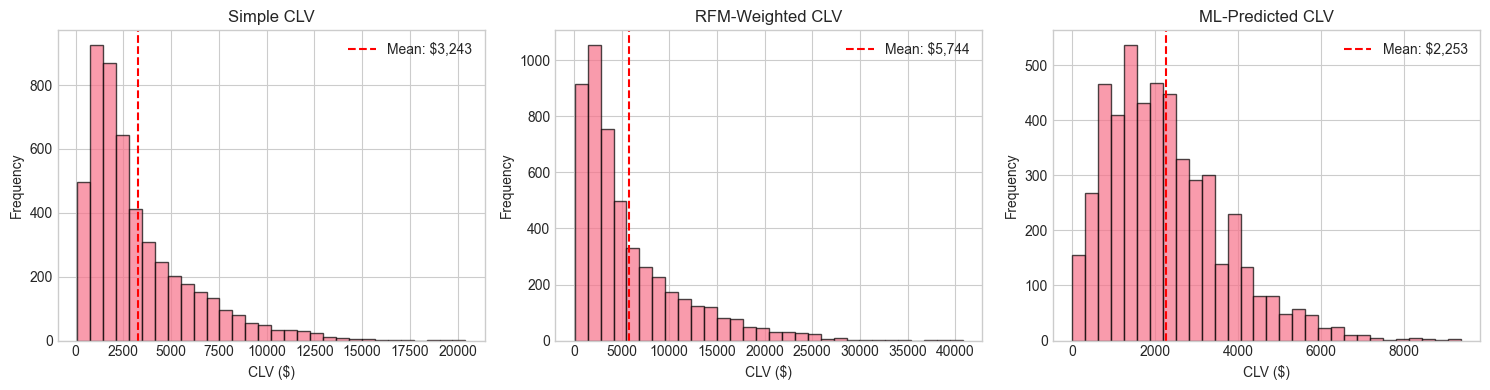

In [15]:
# Visualize CLV distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clv_cols = ['clv_simple', 'clv_rfm_weighted', 'clv_predicted']
titles = ['Simple CLV', 'RFM-Weighted CLV', 'ML-Predicted CLV']

for ax, col, title in zip(axes, clv_cols, titles):
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel('CLV ($)')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               label=f"Mean: ${df[col].mean():,.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

## 4. CLV Segmentation

In [16]:
# Create CLV tiers based on predicted CLV (quintiles)
df['clv_tier'] = pd.qcut(
    df['clv_predicted'].rank(method='first'),
    q=5,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
)

# Summary by tier
clv_tier_summary = df.groupby('clv_tier').agg({
    'clv_predicted': ['count', 'mean', 'sum'],
    'total_spend_12m': 'mean',
    'total_purchases_12m': 'mean',
    'loyalty_program_member': 'mean'
}).round(2)

clv_tier_summary.columns = ['Count', 'Avg CLV', 'Total CLV', 'Avg Spend 12m', 'Avg Purchases', 'Loyalty %']
clv_tier_summary['Loyalty %'] = (clv_tier_summary['Loyalty %'] * 100).round(1)
print("CLV Tier Summary:")
print(clv_tier_summary)

CLV Tier Summary:
          Count  Avg CLV   Total CLV  Avg Spend 12m  Avg Purchases  Loyalty %
clv_tier                                                                     
Bronze     1000   627.90   627897.23         394.52           8.90        2.0
Silver     1000  1363.83  1363830.19         722.47          12.05        8.0
Gold       1000  2024.91  2024913.08         999.00          14.94       25.0
Platinum   1000  2810.08  2810084.11        1324.29          18.41       52.0
Diamond    1000  4439.40  4439400.05        2080.39          23.20       80.0


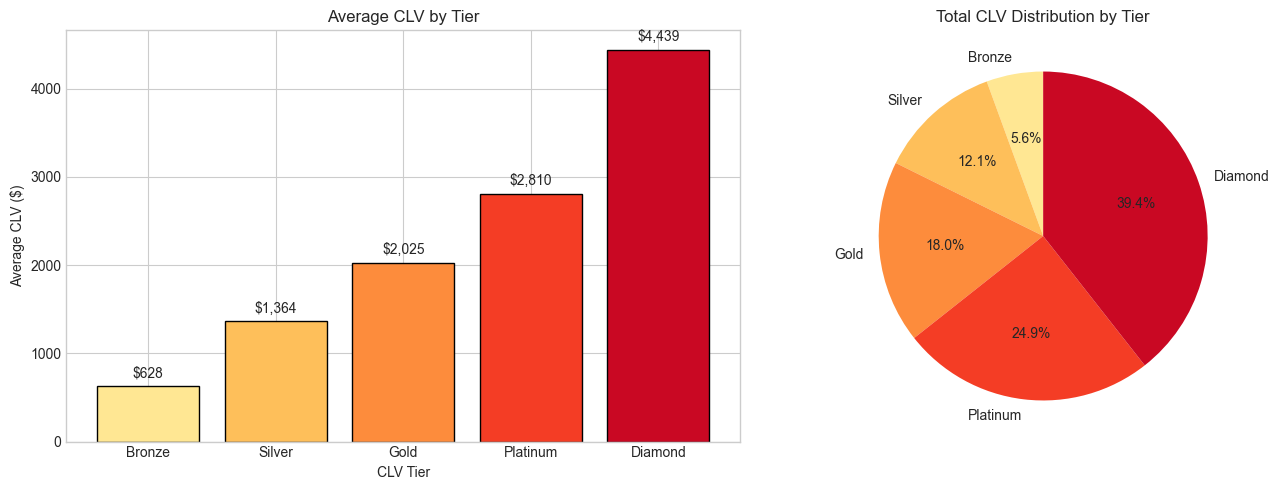

In [17]:
# Visualize CLV by tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average CLV by tier
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
tier_means = df.groupby('clv_tier')['clv_predicted'].mean().reindex(tier_order)
colors = sns.color_palette('YlOrRd', 5)

axes[0].bar(tier_order, tier_means, color=colors, edgecolor='black')
axes[0].set_xlabel('CLV Tier')
axes[0].set_ylabel('Average CLV ($)')
axes[0].set_title('Average CLV by Tier')
for i, v in enumerate(tier_means):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)

# Total CLV by tier (pie chart)
tier_totals = df.groupby('clv_tier')['clv_predicted'].sum().reindex(tier_order)
axes[1].pie(tier_totals, labels=tier_order, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Total CLV Distribution by Tier')

plt.tight_layout()
plt.show()

## 5. CLV Visualizations

### 5.1 CLV vs RFM Heatmap

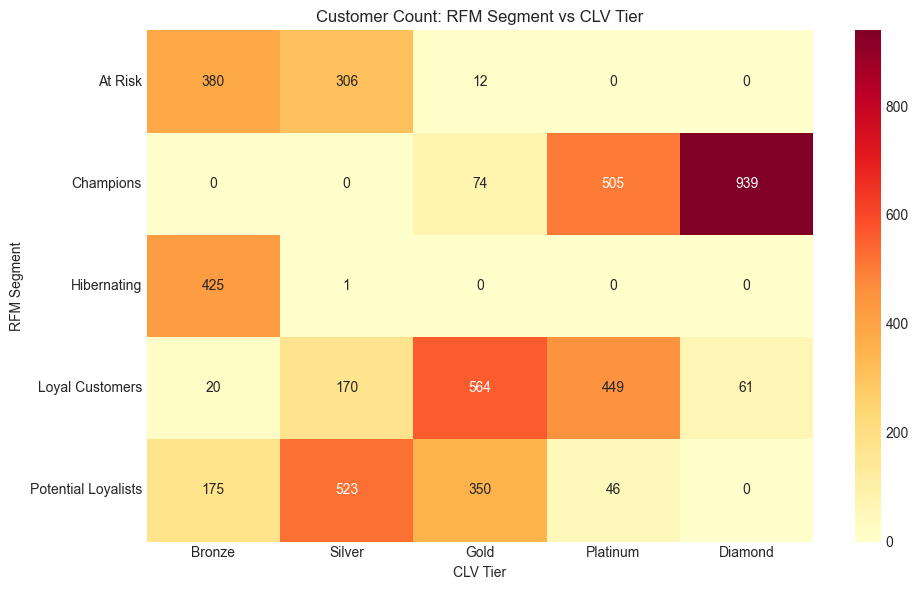

In [18]:
# CLV vs RFM Segment heatmap
clv_rfm_matrix = df.groupby(['rfm_segment', 'clv_tier']).size().unstack(fill_value=0)

# Reorder columns
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
clv_rfm_matrix = clv_rfm_matrix.reindex(columns=tier_order)

plt.figure(figsize=(10, 6))
sns.heatmap(clv_rfm_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Customer Count: RFM Segment vs CLV Tier')
plt.xlabel('CLV Tier')
plt.ylabel('RFM Segment')
plt.tight_layout()
plt.show()

### 5.2 Feature Importance (SHAP)

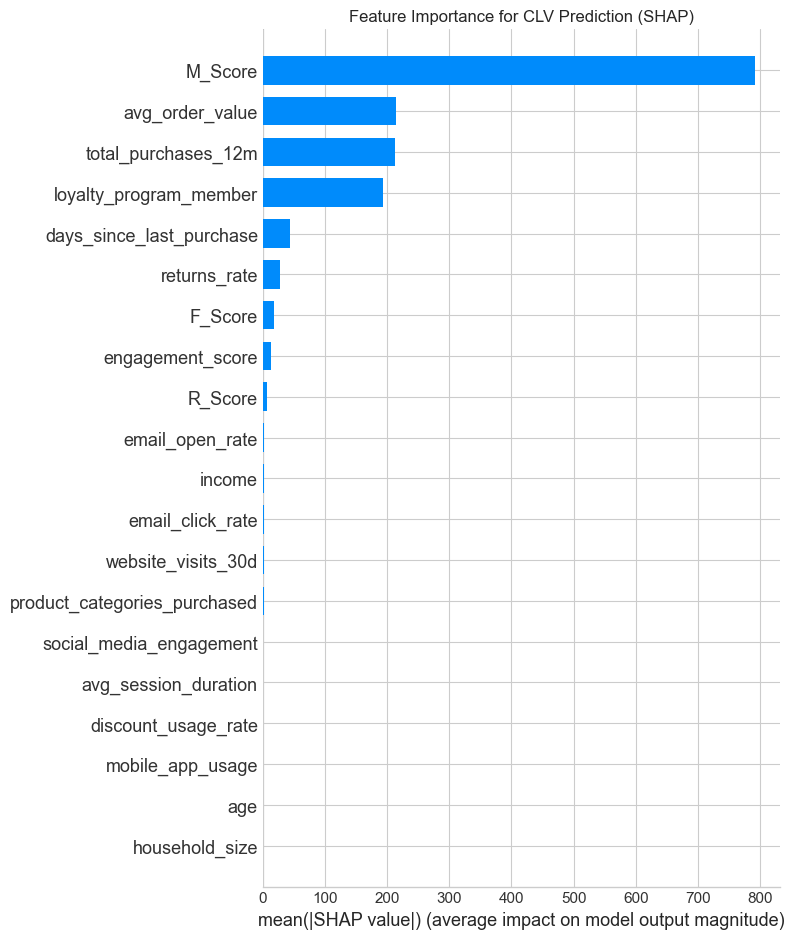

In [19]:
# SHAP analysis for CLV model
explainer = shap.TreeExplainer(clv_model)
shap_values = explainer.shap_values(X)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('Feature Importance for CLV Prediction (SHAP)')
plt.tight_layout()
plt.show()

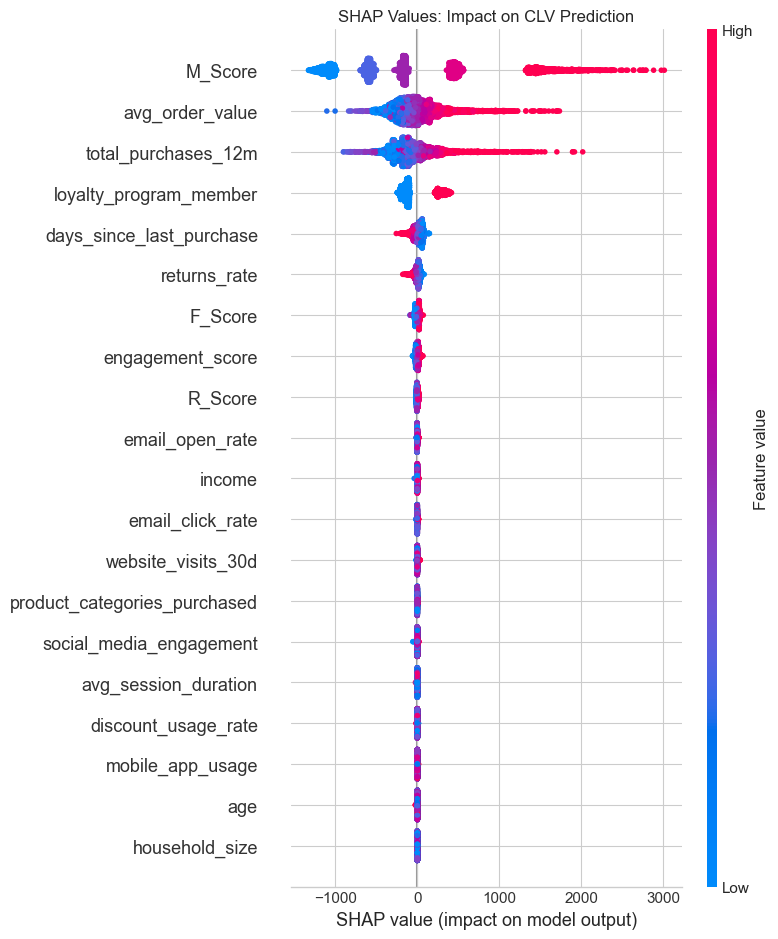

In [20]:
# Detailed SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP Values: Impact on CLV Prediction')
plt.tight_layout()
plt.show()

### 5.3 CLV by Action Segments

In [21]:
# CLV by existing action segments
action_clv = df.groupby('action_segment_3d').agg({
    'clv_predicted': ['mean', 'sum', 'count'],
    'purchased_product_a': 'mean'
}).round(2)

action_clv.columns = ['Avg CLV', 'Total CLV', 'Count', 'Purchase Rate']
action_clv['Purchase Rate'] = (action_clv['Purchase Rate'] * 100).round(1)
action_clv = action_clv.sort_values('Avg CLV', ascending=False)

print("CLV by Action Segment:")
print(action_clv)

CLV by Action Segment:
                                 Avg CLV   Total CLV  Count  Purchase Rate
action_segment_3d                                                         
2. VIP Ready - Convert Now       3775.49  1529072.48    405           92.0
1. VIP Champions - Maximize      3766.74  1103654.83    293           96.0
5. Loyal Engaged - Nurture       3194.68   805059.95    252           53.0
8. Declining VIPs - Win Back     2849.05  1250732.59    439           11.0
6. Potential Stars - Develop     2810.60  1495240.90    532           63.0
9. Fading Interest - Re-engage   2184.65  3294448.10   1508           11.0
7. Fence Sitters - Persuade      1335.82   165641.07    124           87.0
4. Hidden Opportunity - Target   1305.83    70515.01     54           96.0
3. Engaged Prospects - Activate  1246.83    44886.00     36          100.0
10. Dormant - Minimal Effort     1110.44  1506873.74   1357           11.0


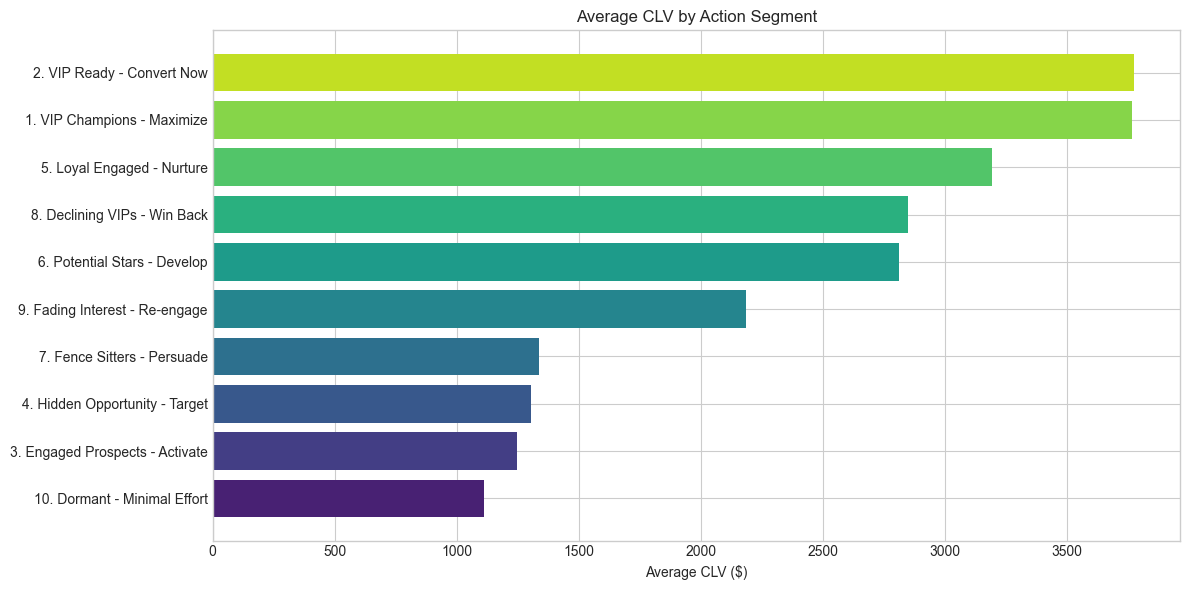

In [22]:
# Visualize
plt.figure(figsize=(12, 6))
action_clv_sorted = action_clv.sort_values('Avg CLV', ascending=True)
plt.barh(range(len(action_clv_sorted)), action_clv_sorted['Avg CLV'], color=sns.color_palette('viridis', len(action_clv_sorted)))
plt.yticks(range(len(action_clv_sorted)), action_clv_sorted.index)
plt.xlabel('Average CLV ($)')
plt.title('Average CLV by Action Segment')
plt.tight_layout()
plt.show()

### 5.4 CLV Distribution by Key Characteristics

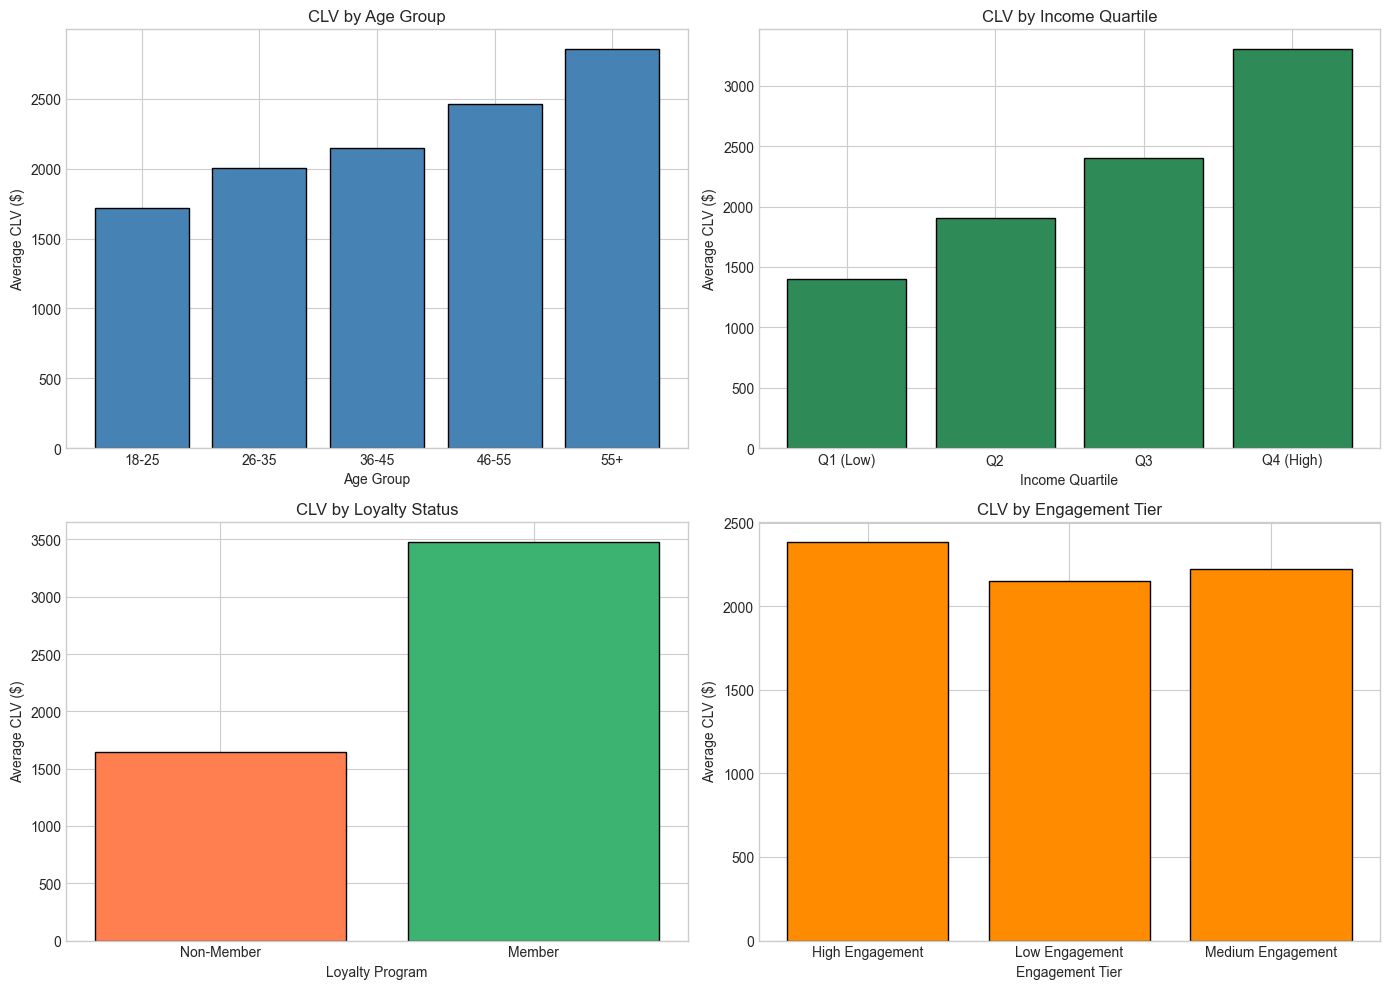

In [23]:
# CLV by key characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Age Group
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])
age_clv = df.groupby('age_group')['clv_predicted'].mean()
axes[0, 0].bar(age_clv.index.astype(str), age_clv.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Average CLV ($)')
axes[0, 0].set_title('CLV by Age Group')

# By Income Quartile
df['income_quartile'] = pd.qcut(df['income'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
income_clv = df.groupby('income_quartile')['clv_predicted'].mean()
axes[0, 1].bar(income_clv.index.astype(str), income_clv.values, color='seagreen', edgecolor='black')
axes[0, 1].set_xlabel('Income Quartile')
axes[0, 1].set_ylabel('Average CLV ($)')
axes[0, 1].set_title('CLV by Income Quartile')

# By Loyalty Status
loyalty_clv = df.groupby('loyalty_program_member')['clv_predicted'].mean()
axes[1, 0].bar(['Non-Member', 'Member'], loyalty_clv.values, color=['coral', 'mediumseagreen'], edgecolor='black')
axes[1, 0].set_xlabel('Loyalty Program')
axes[1, 0].set_ylabel('Average CLV ($)')
axes[1, 0].set_title('CLV by Loyalty Status')

# By Engagement Tier
engagement_clv = df.groupby('engagement_tier')['clv_predicted'].mean()
axes[1, 1].bar(engagement_clv.index.astype(str), engagement_clv.values, color='darkorange', edgecolor='black')
axes[1, 1].set_xlabel('Engagement Tier')
axes[1, 1].set_ylabel('Average CLV ($)')
axes[1, 1].set_title('CLV by Engagement Tier')

plt.tight_layout()
plt.show()

## 6. Summary & Export

In [24]:
# Summary statistics
print("=" * 60)
print("CLV ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nTotal Customers: {len(df):,}")
print(f"\nCLV Method Comparison:")
print(f"  Simple CLV:       Mean ${df['clv_simple'].mean():,.0f}, Total ${df['clv_simple'].sum():,.0f}")
print(f"  RFM-Weighted CLV: Mean ${df['clv_rfm_weighted'].mean():,.0f}, Total ${df['clv_rfm_weighted'].sum():,.0f}")
print(f"  ML-Predicted CLV: Mean ${df['clv_predicted'].mean():,.0f}, Total ${df['clv_predicted'].sum():,.0f}")
print(f"\nCLV Model Performance (R2): {r2_score(y_test, y_pred_test):.4f}")
print(f"\nCLV Tier Distribution:")
print(df['clv_tier'].value_counts().sort_index())

CLV ANALYSIS SUMMARY

Total Customers: 5,000

CLV Method Comparison:
  Simple CLV:       Mean $3,243, Total $16,212,713
  RFM-Weighted CLV: Mean $5,744, Total $28,718,359
  ML-Predicted CLV: Mean $2,253, Total $11,266,125

CLV Model Performance (R2): 0.9951

CLV Tier Distribution:
clv_tier
Bronze      1000
Silver      1000
Gold        1000
Platinum    1000
Diamond     1000
Name: count, dtype: int64


In [25]:
# New columns added
new_columns = [
    'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
    'base_lifespan', 'customer_lifespan_years', 'purchase_frequency_annual',
    'clv_simple', 'clv_rfm_weighted', 'clv_proxy', 'clv_predicted', 'clv_tier',
    'age_group', 'income_quartile'
]

print(f"\nNew columns added: {len(new_columns)}")
print(new_columns)


New columns added: 14
['R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'base_lifespan', 'customer_lifespan_years', 'purchase_frequency_annual', 'clv_simple', 'clv_rfm_weighted', 'clv_proxy', 'clv_predicted', 'clv_tier', 'age_group', 'income_quartile']


In [26]:
# Export dataset with CLV columns
df.to_csv('data/customers_with_clv.csv', index=False)
print(f"\nExported to: data/customers_with_clv.csv")
print(f"Total columns: {len(df.columns)}")
print(f"Total rows: {len(df)}")


Exported to: data/customers_with_clv.csv
Total columns: 54
Total rows: 5000


In [27]:
# Preview final dataset
print("\nFinal Dataset Preview (CLV columns):")
df[['customer_lifespan_years', 'clv_simple', 'clv_rfm_weighted', 'clv_predicted', 'clv_tier']].head(10)


Final Dataset Preview (CLV columns):


,customer_lifespan_years,clv_simple,clv_rfm_weighted,clv_predicted,clv_tier
0,2.20000,1269.268000,1946.210933,1198.551749,Silver
1,2.50000,1854.300000,2842.991667,1412.292309,Silver
2,3.85000,7874.212500,15223.105333,4533.551498,Diamond
3,1.70000,1512.320000,2218.019467,1589.421251,Silver
4,3.50000,7251.090000,14018.300333,4529.590286,Diamond
5,2.50000,1215.550000,1782.806667,947.670924,Bronze
6,3.27250,3546.571875,5437.876162,2456.759611,Platinum
7,1.66175,2452.211240,4087.184908,2719.057156,Platinum
8,3.03450,1419.781860,1893.244780,1311.173459,Silver
9,4.20000,2762.760000,4604.180000,1768.787317,Gold
